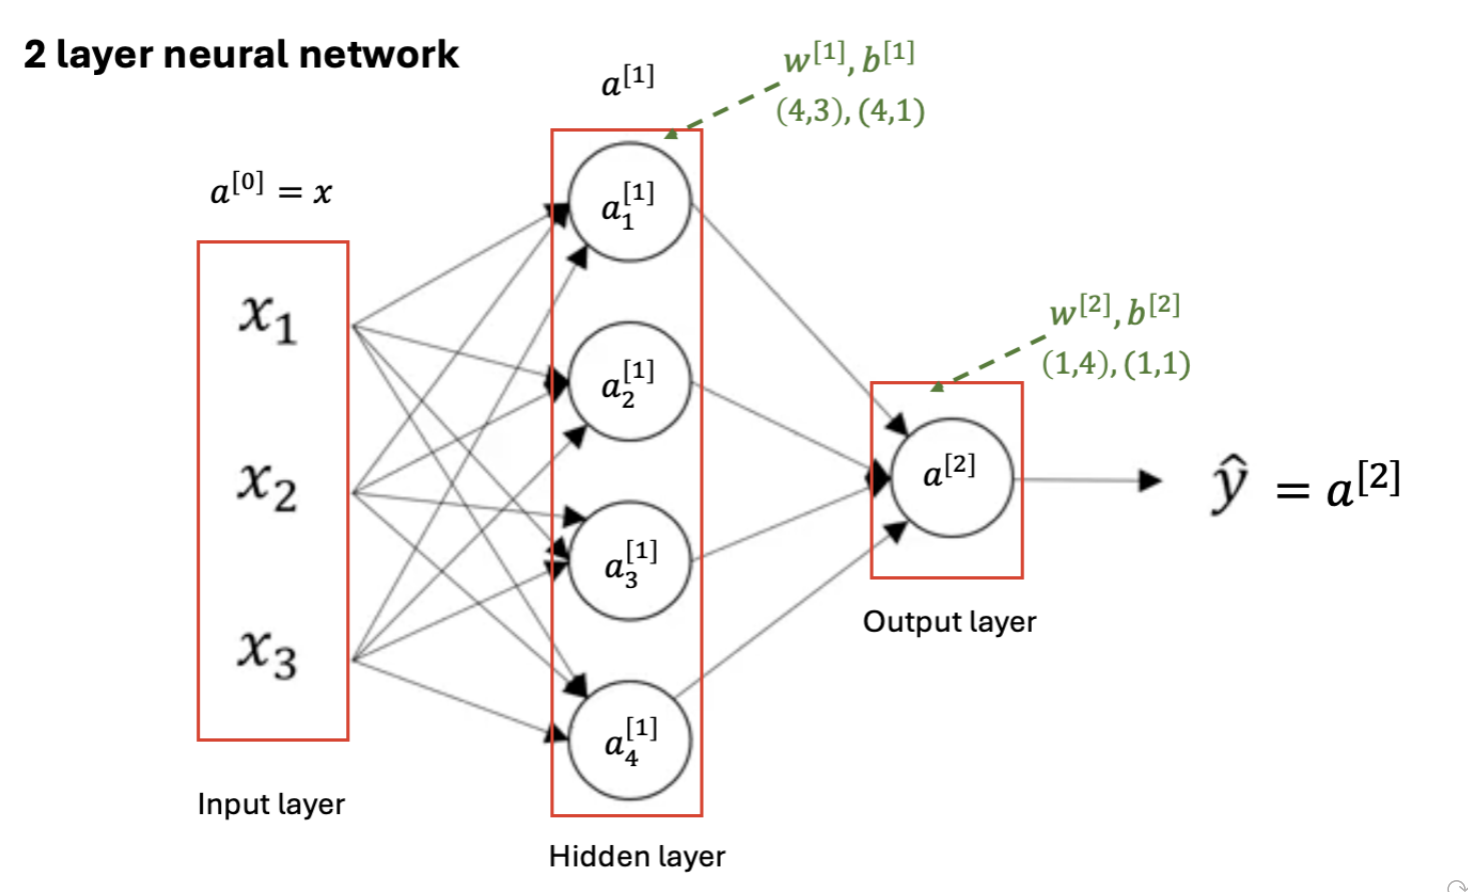

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist

Load the data

In [3]:
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# flatten and normalize the images
X_train = X_train_orig.reshape(X_train_orig.shape[0], -1).T / 255.0
X_test = X_test_orig.reshape(X_test_orig.shape[0], -1).T / 255.0

In [5]:
# convert labels for binary classification (0 vs not 0)
y_train = (y_train_orig == 0).astype(int).reshape(1, -1)
y_test = (y_test_orig == 0).astype(int).reshape(1, -1)

In [7]:
np.random.seed(1)

m = X_train.shape[1] # number of samples
perm = np.random.permutation(m) # shuffling

X_train = X_train[:, perm]
y_train = y_train[:, perm]

split = int(0.9 * m) # 90% train, 10% validation

# val
X_val = X_train[:, split:]
y_val = y_train[:, split:]

# training
X_train = X_train[:, :split]
y_train = y_train[:, :split]

In [8]:
print('Dataset sizes: ')
print('Train set: ', X_train.shape, y_train.shape)
print('Validation set: ', X_val.shape, y_val.shape)
print('Test set: ', X_test.shape, y_test.shape)

Dataset sizes: 
Train set:  (784, 48600) (1, 48600)
Validation set:  (784, 5400) (1, 5400)
Test set:  (784, 10000) (1, 10000)


In [21]:
# X.shape = (n_x, m) -> (784, 48600)
# n_x number of input features
# m is n of training examples

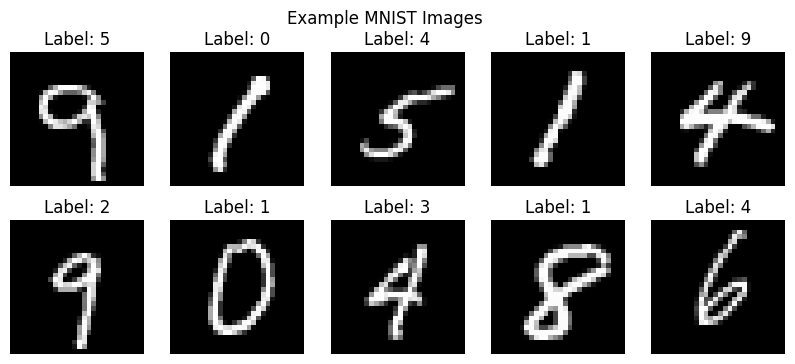

In [11]:
plt.figure(figsize=(10, 4))

for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[:, i].reshape(28, 28), cmap='gray')
  plt.title(f'Label: {y_train_orig[i]}')
  plt.axis('off')

plt.suptitle('Example MNIST Images')
plt.show()

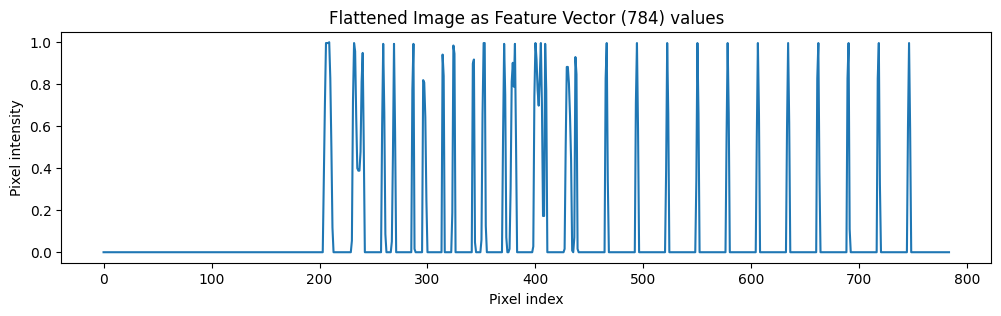

In [13]:
sample = X_train[:, 0]

plt.figure(figsize=(12, 3))
plt.plot(sample)
plt.title('Flattened Image as Feature Vector (784) values')
plt.xlabel('Pixel index')
plt.ylabel('Pixel intensity')
plt.show()

28x28 image -> flattened -> 784 features

This is the input to the neural network

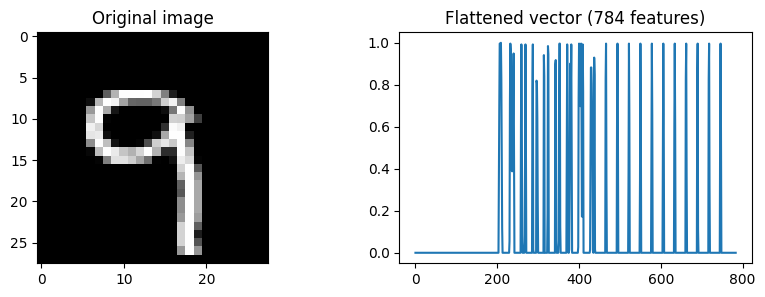

In [16]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.imshow(X_train[:, 0].reshape(28, 28), cmap='gray')
plt.title('Original image')

plt.subplot(1, 2, 2)
plt.plot(X_train[:, 0])
plt.title('Flattened vector (784 features)')

plt.show()

Image -> vector -> neural network input

NN do not see images, they see numbers -> that's why we are converting images into vectors of numbers

In [34]:
def sigmoid(Z):
  return 1 / (1 + np.exp(-Z))

def relu(Z):
  return np.maximum(0, Z)

def tanh(z):
  return np.tanh(z)

In [18]:
def sigmoid_derivative(z):
  s = sigmoid(z)
  return s * (1 - s)

def relu_derivative(z):
  return (z > 0).astype(float)

def tanh_derivative(z):
  return 1 - np.tanh(z)**2

In [19]:
def initialize_nn_params(n_x, n_h, n_y):
  np.random.seed(1)
  W1 = np.random.randn(n_h, n_x) * 0.01
  b1 = np.zeros((n_h, 1))
  W2 = np.random.randn(n_y, n_h) * 0.01
  b2 = np.zeros((n_y, 1))

  return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

In [22]:
def forward_propagation_nn(X, activation_fn, params):
  W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]

  # hidden layer
  Z1 = np.dot(W1, X) + b1
  A1 = activation_fn(Z1)

  # output layer
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  cache = {"Z1": Z1, "A1": A1, "Z2":Z2, "A2":A2}

  return A2, cache

In [24]:
def backward_pass_nn(X, y, params, cache, activation_fn_derivative):
  W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
  Z1, A1, Z2, A2 = cache["Z1"], cache["A1"], cache["Z2"], cache["A2"]

  m = X.shape[1]

  # output layer
  dZ2 = A2 - y # (1, m)
  dW2 = (1/m) * np.dot(dZ2, A1.T) # (1, n_h)
  db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True) # (1, 1)

  # hidden layer
  dA1 = np.dot(W2.T, dZ2) # (n_h, m)
  dZ1 = dA1 * activation_fn_derivative(Z1) # (n_h, m)
  dW1 = (1/m) * np.dot(dZ1, X.T) # (n_h, n_x)
  db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True) # (n_h, 1)

  return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

In [25]:
def predict_nn(params, activation_fn, X):
  A2, _ = forward_propagation_nn(X, activation_fn, params)
  return (A2 > 0.5).astype(int)

In [29]:
def predict_from_probs(A2, threshold=0.5):
  return (A2 >= threshold).astype(int)

In [36]:
def compute_cost(A2, y):
  m = y.shape[1]

  A2 = np.clip(A2, 1e-9, 1 - 1e-9)

  return - (1/m) * np.sum(y * np.log(A2) + (1 - y) * np.log(1 - A2))

In [27]:
def accuracy(y_pred, y_true):
  return np.mean(y_pred == y_true) * 100

In [28]:
def update_parameters(params, grads, lr):
  params["W1"] -= lr * grads["dW1"]
  params["b1"] -= lr * grads["db1"]
  params["W2"] -= lr * grads["dW2"]
  params["b2"] -= lr * grads["db2"]

  return params

In [30]:
def train_one_activation(X_train, y_train, X_val, y_val, activation_fn, activation_fn_derivative, n_h=16, lr=0.01, epochs=300,
                         eval_every=10, print_every=50, seed=1):
  n_x = X_train.shape[0]
  params = initialize_nn_params(n_x, n_h, 1)

  steps, train_losses, val_losses, train_accs, val_accs = [], [], [], [], []

  for epoch in range(epochs + 1):

    # TRAIN
    A2_train, cache = forward_propagation_nn(X_train, activation_fn, params)
    train_cost = compute_cost(A2_train, y_train)

    grads = backward_pass_nn(X_train, y_train, params, cache, activation_fn_derivative)
    params = update_parameters(params, grads, lr)

    # eval + store (train + val)

    if epoch % eval_every == 0:
      yhat_train = predict_from_probs(A2_train)
      train_acc = accuracy(yhat_train, y_train)

      A2_val, _ = forward_propagation_nn(X_val, activation_fn, params)
      val_cost = compute_cost(A2_val, y_val)
      yhat_val = predict_from_probs(A2_val)
      val_acc = accuracy(yhat_val, y_val)

      steps.append(epoch)
      train_losses.append(train_cost)
      val_losses.append(val_cost)
      train_accs.append(train_acc)
      val_accs.append(val_acc)

    # print
    if epoch % print_every == 0:
      print(f"Epoch {epoch:4d} | Train cost: {train_cost:.4f}")

  history = {
      "steps": np.array(steps),
      "train_loss": np.array(train_losses),
      "val_loss": np.array(val_losses),
      "train_acc": np.array(train_accs),
      "val_acc": np.array(val_accs)

  }

  return params, history

In [32]:
def plot_histories_by_activation(histories):

  # loss
  plt.figure()
  for name, h in histories.items():
    plt.plot(h["steps"], h["train_loss"], label=f'{name} train')
  plt.title("Loss: Train vs Validation")
  plt.xlabel('Epoch')
  plt.ylabel('Binary Cross-Entropy Loss')
  plt.legend()
  plt.show()

  # accuracy
  plt.figure()
  for name, h in histories.items():
    plt.plot(h["steps"], h["train_acc"], label=f'{name} train')
  plt.title("Accuracy: Train vs Validation")
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()
  plt.show()


In [37]:
lr = 0.01

activations = {
    'ReLU': (relu, relu_derivative),
    'tanh': (tanh, tanh_derivative),
    'sigmoid': (sigmoid, sigmoid_derivative)
}

histories = {}

for name, (act_fn, act_deriv) in activations.items():
  print(f'\nTraining with {name}')
  _, history = train_one_activation(
      X_train, y_train, X_val, y_val, activation_fn=act_fn, activation_fn_derivative=act_deriv, lr=0.01, epochs=300
  )

  histories[name] = history


Training with ReLU
Epoch    0 | Train cost: 0.6933
Epoch   50 | Train cost: 0.6173
Epoch  100 | Train cost: 0.5408
Epoch  150 | Train cost: 0.4387
Epoch  200 | Train cost: 0.3511
Epoch  250 | Train cost: 0.3051
Epoch  300 | Train cost: 0.2717

Training with tanh
Epoch    0 | Train cost: 0.6931
Epoch   50 | Train cost: 0.6115
Epoch  100 | Train cost: 0.5208
Epoch  150 | Train cost: 0.4243
Epoch  200 | Train cost: 0.3602
Epoch  250 | Train cost: 0.3245
Epoch  300 | Train cost: 0.2972

Training with sigmoid
Epoch    0 | Train cost: 0.6932
Epoch   50 | Train cost: 0.4563
Epoch  100 | Train cost: 0.3756
Epoch  150 | Train cost: 0.3434
Epoch  200 | Train cost: 0.3281
Epoch  250 | Train cost: 0.3193
Epoch  300 | Train cost: 0.3131


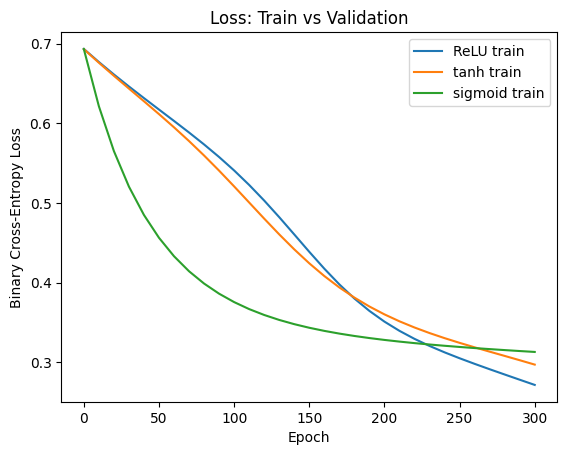

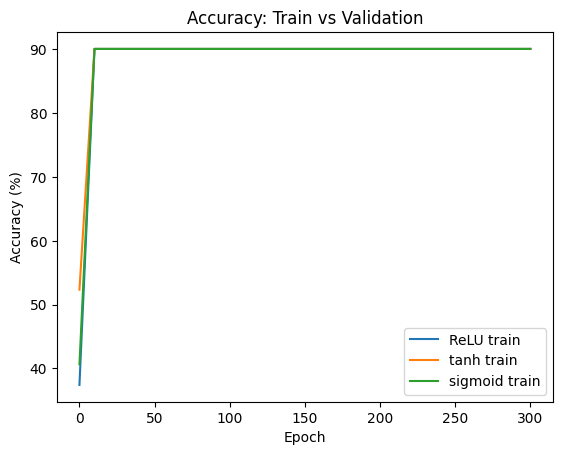

In [38]:
plot_histories_by_activation(histories)